# Cohort-Based CLV Forecasting with PyMC-Marketing (KT Weekly Dataset)

This notebook implements a **cohort-based approach** to Customer Lifetime Value (CLV)
forecasting using PyMC-Marketing's BG/NBD and Gamma-Gamma models.

## Approach

Instead of fitting a single model to all customers, we fit separate models
per **weekly** cohort. This addresses two key challenges:

1. **Dataset Size**: Each cohort has a manageable number of customers
2. **Seasonality**: Different cohorts capture seasonal acquisition patterns implicitly

## Models

- **BG/NBD (Beta-Geometric/NBD)**: Models customer purchase frequency and dropout
- **Gamma-Gamma**: Models monetary value of transactions

## Data Source

KT dataset with weekly cohorts.

---
## 1. Setup and Configuration

**Global Parameters:**

- `MAX_COHORT_SIZE`: Controls subsampling for faster testing/debugging.
  - Set to an integer (e.g., 10000) to subsample large cohorts
  - Set to `None` for production runs with full data

**Usage:**
```python
MAX_COHORT_SIZE = 10000  # Fast testing
MAX_COHORT_SIZE = None   # Full dataset (production run)
```

In [1]:
from __future__ import annotations

import time
from datetime import date, timedelta
from typing import Any

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import xarray as xr
from pymc_extras.prior import Prior
from pymc_marketing.clv import BetaGeoModel, GammaGammaModel

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

In [2]:
MAX_COHORT_SIZE: int | None = None

SEED: int = sum(map(ord, "kt_weekly_clv"))
RNG: np.random.Generator = np.random.default_rng(seed=SEED)

BG_NBD_MODEL_CONFIG: dict[str, Prior] = {
    "a": Prior("HalfNormal", sigma=5),
    "b": Prior("HalfNormal", sigma=5),
    "alpha": Prior("HalfNormal", sigma=5),
    "r": Prior("HalfNormal", sigma=5),
}

BG_NBD_MODEL_CONFIG_TIGHT: dict[str, Prior] = {
    "a": Prior("HalfNormal", sigma=2),
    "b": Prior("HalfNormal", sigma=2),
    "alpha": Prior("HalfNormal", sigma=5),
    "r": Prior("HalfNormal", sigma=2),
}

BG_NBD_MODEL_CONFIG_VERY_TIGHT: dict[str, Prior] = {
    "a": Prior("HalfNormal", sigma=1),
    "b": Prior("HalfNormal", sigma=1),
    "alpha": Prior("HalfNormal", sigma=2),
    "r": Prior("HalfNormal", sigma=1),
}

GAMMA_GAMMA_MODEL_CONFIG: dict[str, Prior] = {
    "p": Prior("HalfNormal", sigma=5),
    "q": Prior("HalfNormal", sigma=5),
    "v": Prior("HalfNormal", sigma=50),
}

print(f"MAX_COHORT_SIZE: {MAX_COHORT_SIZE}")
print(f"SEED: {SEED}")

MAX_COHORT_SIZE: None
SEED: 1395


---
## 2. Data Loading and Exploration

We load the KT dataset containing:
- `customer`: Unique customer identifier
- `date`: Transaction date
- `value`: Transaction amount

Values are normalized so that the mean transaction value equals 10.0.

In [3]:
data_path = "/Users/juanitorduz/Dropbox/cohort-revenue-retention-paper/data/KT/kt.csv"
raw_df = pl.read_csv(data_path, try_parse_dates=True)

print(f"Raw data shape: {raw_df.shape}")
raw_df.head()

Raw data shape: (18621046, 5)


customer,basket,date,store,value
i64,i64,date,i64,f64
1,7395022,2015-04-13,82934,4.35
1,9251168,2015-04-15,82535,5.69
1,11386596,2015-04-15,82535,3.76
1,5561542,2015-05-02,9,12.27
1,15960613,2015-05-16,8,51.35


In [4]:
target_mean = 10.0
raw_value_mean = raw_df["value"].mean()
raw_df = raw_df.with_columns(pl.col("value") * (target_mean / raw_value_mean))
assert raw_df["value"].mean() == target_mean

In [5]:
raw_df = raw_df.rename({"customer": "customer_id", "date": "t_dat", "value": "price"})

In [6]:
print(f"Date range: {raw_df['t_dat'].min()} to {raw_df['t_dat'].max()}")
print(f"Number of unique customers: {raw_df['customer_id'].n_unique():,}")
print(f"Number of transactions: {raw_df.height:,}")
print(f"Total revenue: {raw_df['price'].sum():,.2f}")

Date range: 2015-04-09 to 2017-03-30
Number of unique customers: 562,096
Number of transactions: 18,621,046
Total revenue: 186,210,460.00


---
## 3. Train/Test Split Definition

We use a temporal split:
- **Training**: All transactions up to August 31, 2016
- **Test**: September through November 2016 (~13 weeks)

In [7]:
DATA_START_DATE = date(2015, 7, 1)
PERIOD_TRAIN_TEST_SPLIT = date(2016, 8, 31)
TEST_PERIOD_END = date(2016, 11, 28)

print(f"Training period: {DATA_START_DATE} to {PERIOD_TRAIN_TEST_SPLIT}")
print(f"Test period: {PERIOD_TRAIN_TEST_SPLIT} to {TEST_PERIOD_END}")

Training period: 2015-07-01 to 2016-08-31
Test period: 2016-08-31 to 2016-11-28


In [8]:
filtered_df = raw_df.filter(
    (pl.col("t_dat") >= DATA_START_DATE) & (pl.col("t_dat") < TEST_PERIOD_END)
)

print(f"Filtered data shape: {filtered_df.shape}")
date_min = filtered_df["t_dat"].min()
date_max = filtered_df["t_dat"].max()
print(f"Date range after filtering: {date_min} to {date_max}")

Filtered data shape: (15234327, 5)
Date range after filtering: 2015-07-01 to 2016-11-27


---
## 4. Cohort Assignment

**Cohort Definition**: A customer's cohort is determined by their **first purchase week**.

In [9]:
customers_with_cohort_df = (
    filtered_df.with_columns(pl.col("t_dat").dt.truncate("1w").alias("period"))
    .with_columns(pl.col("period").min().over("customer_id").alias("cohort"))
    .sort(["customer_id", "t_dat"])
)

print(
    f"Customers with cohort assigned: {customers_with_cohort_df.height:,} transactions"
)
customers_with_cohort_df.head(10)

Customers with cohort assigned: 15,234,327 transactions


customer_id,basket,t_dat,store,price,period,cohort
i64,i64,date,i64,f64,date,date
2,7578669,2015-08-17,148,3.320007,2015-08-17,2015-08-17
2,780704,2015-08-18,148,2.12766,2015-08-17,2015-08-17
2,3873026,2015-08-18,148,1.956305,2015-08-17,2015-08-17
2,5006776,2015-08-18,148,2.156219,2015-08-17,2015-08-17
2,12246244,2015-08-20,148,7.83236,2015-08-17,2015-08-17
2,7855348,2015-08-21,148,2.277596,2015-08-17,2015-08-17
2,9018064,2015-08-21,148,7.182638,2015-08-17,2015-08-17
2,10899156,2015-08-21,148,12.694563,2015-08-17,2015-08-17
2,3431469,2015-08-24,148,3.341426,2015-08-24,2015-08-17


In [10]:
cohort_sizes = (
    customers_with_cohort_df.group_by("cohort")
    .agg(
        pl.col("customer_id").n_unique().alias("n_customers"),
        pl.col("price").sum().alias("total_revenue"),
        pl.col("t_dat").count().alias("n_transactions"),
    )
    .sort("cohort")
)

print("Cohort Summary:")
print(cohort_sizes)

Cohort Summary:
shape: (74, 4)
┌────────────┬─────────────┬───────────────┬────────────────┐
│ cohort     ┆ n_customers ┆ total_revenue ┆ n_transactions │
│ ---        ┆ ---         ┆ ---           ┆ ---            │
│ date       ┆ u32         ┆ f64           ┆ u32            │
╞════════════╪═════════════╪═══════════════╪════════════════╡
│ 2015-06-29 ┆ 101942      ┆ 7.2354e7      ┆ 7163720        │
│ 2015-07-06 ┆ 55007       ┆ 2.2666e7      ┆ 2209387        │
│ 2015-07-13 ┆ 29507       ┆ 9.0119e6      ┆ 903767         │
│ 2015-07-20 ┆ 20223       ┆ 5.2276e6      ┆ 534859         │
│ 2015-07-27 ┆ 14969       ┆ 3.5435e6      ┆ 361076         │
│ …          ┆ …           ┆ …             ┆ …              │
│ 2016-10-24 ┆ 1466        ┆ 50817.128231  ┆ 5682           │
│ 2016-10-31 ┆ 1476        ┆ 48137.490187  ┆ 5027           │
│ 2016-11-07 ┆ 1378        ┆ 37313.019091  ┆ 3866           │
│ 2016-11-14 ┆ 1373        ┆ 28831.323171  ┆ 2934           │
│ 2016-11-21 ┆ 1338        ┆ 17261.8283

/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_60201/1908868858.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


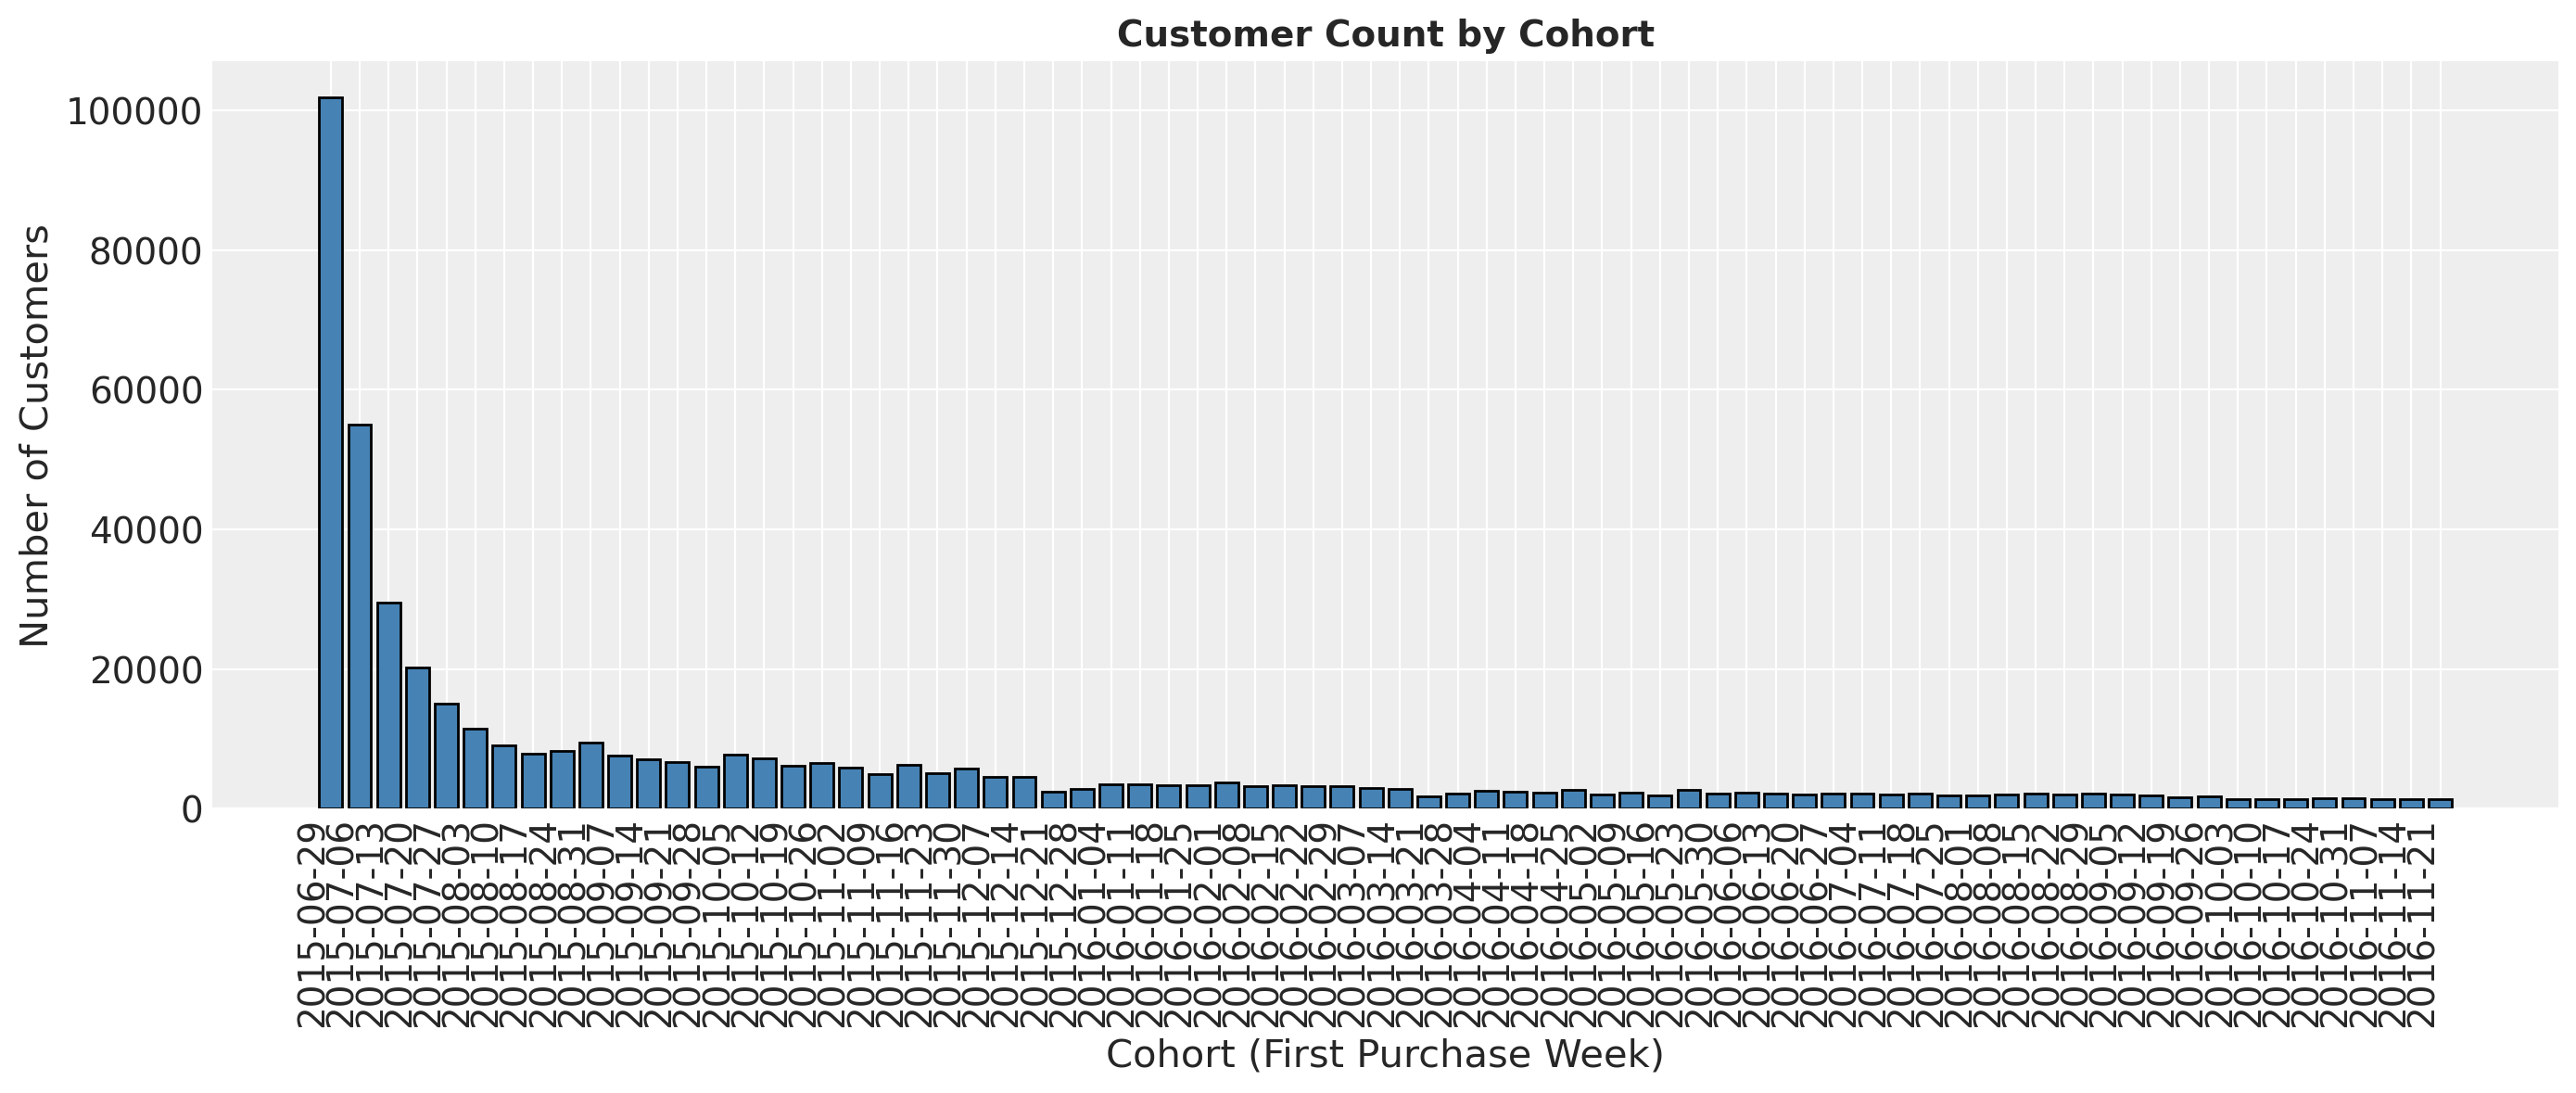

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))
cohort_dates = cohort_sizes["cohort"].to_list()
cohort_customers = cohort_sizes["n_customers"].to_list()

ax.bar(range(len(cohort_dates)), cohort_customers, color="steelblue", edgecolor="black")
ax.set_xticks(range(len(cohort_dates)))
ax.set_xticklabels(
    [d.strftime("%Y-%m-%d") for d in cohort_dates], rotation=90, ha="right"
)
ax.set_xlabel("Cohort (First Purchase Week)")
ax.set_ylabel("Number of Customers")
ax.set_title("Customer Count by Cohort", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

---
## 5. Helper Functions (Data Processing)

These functions handle:
1. Computing RFM (Recency, Frequency, T, Monetary Value) metrics per customer
2. Adding cohort information
3. Summarizing cohort statistics for debugging
4. Subsampling cohorts if `MAX_COHORT_SIZE` is set

**RFM Definitions:**
- `frequency`: Number of *repeat* purchases (total purchases - 1)
- `recency`: Time between first and last purchase (in weeks)
- `T`: Time between first purchase and observation end (in weeks)
- `monetary_value`: Average spend per transaction (for repeat customers)

In [12]:
def compute_rfm_by_cohort(
    transactions_df: pl.DataFrame,
    observation_end: date,
    time_unit: str = "W",
) -> pl.DataFrame:
    """
    Compute RFM metrics with cohort assignment for all customers.

    Parameters
    ----------
    transactions_df : pl.DataFrame
        Raw transactions with columns: customer_id, t_dat, price
    observation_end : date
        End of observation period for T calculation
    time_unit : str
        Time unit for recency and T: "D" (days) or "W" (weeks)

    Returns
    -------
    pl.DataFrame
        Columns: customer_id, frequency, recency, T, monetary_value, cohort
    """
    divisor = {"D": 1, "W": 7, "M": 30}.get(time_unit, 1)

    return (
        transactions_df.with_columns(pl.col("t_dat").dt.truncate("1w").alias("period"))
        .group_by("customer_id")
        .agg(
            pl.col("t_dat").min().alias("first_purchase"),
            pl.col("t_dat").max().alias("last_purchase"),
            pl.col("t_dat").count().alias("n_transactions"),
            pl.col("price").sum().alias("total_spend"),
            pl.col("period").min().alias("cohort"),
        )
        .with_columns(
            (pl.col("n_transactions") - 1).alias("frequency"),
            (
                (pl.col("last_purchase") - pl.col("first_purchase"))
                .dt.total_days()
                .truediv(divisor)
            ).alias("recency"),
            (
                (pl.lit(observation_end) - pl.col("first_purchase"))
                .dt.total_days()
                .truediv(divisor)
            ).alias("T"),
        )
        .with_columns(
            pl.when(pl.col("frequency") > 0)
            .then(pl.col("total_spend") / pl.col("n_transactions"))
            .otherwise(0.0)
            .alias("monetary_value")
        )
        .select(
            "customer_id",
            "frequency",
            "recency",
            "T",
            "monetary_value",
            "cohort",
        )
    )

In [13]:
def get_cohort_summary(rfm_df: pl.DataFrame) -> pl.DataFrame:
    """Summarize cohort sizes and repeat customer counts for debugging."""
    return (
        rfm_df.group_by("cohort")
        .agg(
            pl.col("customer_id").count().alias("n_customers"),
            (pl.col("frequency") > 0).sum().alias("n_repeat"),
            pl.col("frequency").mean().alias("avg_frequency"),
            pl.col("monetary_value")
            .filter(pl.col("frequency") > 0)
            .mean()
            .alias("avg_monetary"),
        )
        .with_columns(
            (pl.col("n_repeat") / pl.col("n_customers") * 100).alias("pct_repeat")
        )
        .sort("cohort")
    )

In [14]:
def subsample_cohort_if_needed(
    rfm_data: pl.DataFrame,
    max_size: int | None,
    random_seed: int = SEED,
) -> tuple[pl.DataFrame, int, bool]:
    """Subsample cohort data if it exceeds max_size (without replacement)."""
    original_size = rfm_data.height

    if max_size is None:
        return rfm_data, original_size, False

    if rfm_data.height <= max_size:
        return rfm_data, original_size, False

    subsampled = rfm_data.sample(n=max_size, seed=random_seed, with_replacement=False)
    return subsampled, original_size, True

In [15]:
def validate_cohort_data(
    rfm_pd: pd.DataFrame,
    min_customers: int = 20,
    min_repeat_customers: int = 5,
) -> bool:
    """Validate cohort data meets minimum requirements for stable MAP fitting."""
    n_customers = len(rfm_pd)
    n_repeat = (rfm_pd["frequency"] > 0).sum()
    return n_customers >= min_customers and n_repeat >= min_repeat_customers

In [16]:
def validate_fit_result(model) -> bool:
    """Check if model fit produced valid (non-NaN) parameter estimates."""
    try:
        fit_result = model.fit_result
        for var_name in fit_result.data_vars:
            values = fit_result[var_name].to_numpy()
            if np.any(np.isnan(values)) or np.any(np.isinf(values)):
                return False
        return True
    except Exception:
        return False

---
## 6. Compute RFM Data

We compute RFM metrics for the training period (up to the train/test split date).

In [17]:
train_transactions_df = filtered_df.filter(pl.col("t_dat") <= PERIOD_TRAIN_TEST_SPLIT)

print(f"Training transactions: {train_transactions_df.height:,}")
print(f"Training customers: {train_transactions_df['customer_id'].n_unique():,}")

Training transactions: 13,034,965
Training customers: 451,495


In [18]:
train_rfm_df_all = compute_rfm_by_cohort(
    transactions_df=train_transactions_df,
    observation_end=PERIOD_TRAIN_TEST_SPLIT,
    time_unit="W",
)

COHORT_START_DATE = DATA_START_DATE
train_rfm_df = train_rfm_df_all.filter(pl.col("cohort") >= COHORT_START_DATE)

print(f"RFM data shape (all cohorts): {train_rfm_df_all.shape}")
print(f"RFM data shape (filtered cohorts >= {COHORT_START_DATE}): {train_rfm_df.shape}")
train_rfm_df.head(10)

RFM data shape (all cohorts): (451495, 6)
RFM data shape (filtered cohorts >= 2015-07-01): (349553, 6)


customer_id,frequency,recency,T,monetary_value,cohort
i64,u32,f64,f64,f64,date
285254,61,58.428571,60.285714,7.481243,2015-07-06
464951,15,31.857143,45.714286,15.263998,2015-10-12
477813,1,0.428571,43.285714,1.170927,2015-11-02
356432,8,36.0,45.571429,27.681795,2015-10-12
431668,0,0.0,51.571429,0.0,2015-08-31
453825,1,0.142857,47.428571,6.115238,2015-09-28
459446,142,46.285714,46.571429,5.623266,2015-10-05
195063,3,16.142857,60.285714,5.251322,2015-07-06
253906,51,59.571429,60.285714,2.182444,2015-07-06


In [19]:
cohort_summary = get_cohort_summary(train_rfm_df)
print("Cohort Summary (Training Data):")
print(cohort_summary)

Cohort Summary (Training Data):
shape: (61, 6)
┌────────────┬─────────────┬──────────┬───────────────┬──────────────┬────────────┐
│ cohort     ┆ n_customers ┆ n_repeat ┆ avg_frequency ┆ avg_monetary ┆ pct_repeat │
│ ---        ┆ ---         ┆ ---      ┆ ---           ┆ ---          ┆ ---        │
│ date       ┆ u32         ┆ u32      ┆ f64           ┆ f64          ┆ f64        │
╞════════════╪═════════════╪══════════╪═══════════════╪══════════════╪════════════╡
│ 2015-07-06 ┆ 55007       ┆ 50238    ┆ 34.242696     ┆ 10.375252    ┆ 91.330194  │
│ 2015-07-13 ┆ 29507       ┆ 25624    ┆ 25.879046     ┆ 10.198865    ┆ 86.840411  │
│ 2015-07-20 ┆ 20223       ┆ 16801    ┆ 22.150472     ┆ 9.909242     ┆ 83.078673  │
│ 2015-07-27 ┆ 14969       ┆ 12257    ┆ 20.171154     ┆ 10.031622    ┆ 81.882557  │
│ 2015-08-03 ┆ 11451       ┆ 9268     ┆ 19.037901     ┆ 10.240664    ┆ 80.936163  │
│ …          ┆ …           ┆ …        ┆ …             ┆ …            ┆ …          │
│ 2016-08-01 ┆ 1854        ┆ 

In [20]:
total_customers = train_rfm_df.height
n_repeat = train_rfm_df.filter(pl.col("frequency") > 0).height
n_single = train_rfm_df.filter(pl.col("frequency") == 0).height

print("\nOverall Statistics:")
print(f"  Total customers: {total_customers:,}")
print(f"  Repeat customers: {n_repeat:,} ({n_repeat / total_customers:.1%})")
print(f"  Single-purchase customers: {n_single:,} ({n_single / total_customers:.1%})")


Overall Statistics:
  Total customers: 349,553
  Repeat customers: 269,270 (77.0%)
  Single-purchase customers: 80,283 (23.0%)


---
## 7. Helper Functions (Model Fitting)

These functions fit the BG/NBD and Gamma-Gamma models for each cohort.

**Key design decisions:**

- Use MAP estimation by default for speed (MCMC available via `fit_method="mcmc"`)
- Gamma-Gamma requires repeat customers only (frequency > 0)
- Automatically subsamples if `MAX_COHORT_SIZE` is set
- Returns dict with models + metadata for later inspection

In [21]:
def fit_single_cohort(  # noqa: C901
    cohort_id: date,
    rfm_data: pl.DataFrame,
    fit_method: str = "map",
    sampler_kwargs: dict[str, Any] | None = None,
    max_cohort_size: int | None = MAX_COHORT_SIZE,
    min_customers: int = 20,
    min_repeat_customers: int = 5,
    model_config: dict[str, Prior] | None = None,
    max_retries: int = 10,
    *,
    verbose: bool = True,
) -> dict[str, Any]:
    """Fit BG/NBD and Gamma-Gamma models for a single cohort."""
    start_time = time.time()

    rfm_subsampled, original_size, was_subsampled = subsample_cohort_if_needed(
        rfm_data, max_cohort_size
    )

    rfm_pd = rfm_subsampled.to_pandas()

    eps = 1e-6
    rfm_pd["monetary_value"] = rfm_pd["monetary_value"].clip(lower=eps)

    n_customers = len(rfm_pd)
    n_repeat = int((rfm_pd["frequency"] > 0).sum())

    if verbose and was_subsampled:
        print(f"    Subsampled from {original_size:,} to {n_customers:,}")

    if not validate_cohort_data(rfm_pd, min_customers, min_repeat_customers):
        fit_time = time.time() - start_time
        return {
            "cohort_id": cohort_id,
            "bgm": None,
            "ggm": None,
            "rfm_data": rfm_subsampled,
            "rfm_pd": rfm_pd,
            "n_customers": n_customers,
            "n_repeat": n_repeat,
            "original_size": original_size,
            "was_subsampled": was_subsampled,
            "fit_time": fit_time,
            "success": False,
        }

    bgm_config = model_config if model_config is not None else BG_NBD_MODEL_CONFIG

    bgm = None

    for attempt in range(max_retries):
        try:
            bgm = BetaGeoModel(data=rfm_pd, model_config=bgm_config)
            fit_kwargs = sampler_kwargs.copy() if sampler_kwargs else {}
            if fit_method == "map":
                fit_kwargs.setdefault("maxeval", 5000)
                fit_kwargs.setdefault("progressbar", False)
                fit_kwargs["seed"] = (
                    SEED + attempt * 1000 + hash(str(cohort_id)) % 10000
                )
            bgm.fit(method=fit_method, **fit_kwargs)

            if validate_fit_result(bgm):
                break
            bgm = None
        except Exception:
            bgm = None
            continue

    if bgm is None and model_config is None:
        for attempt in range(max_retries):
            try:
                bgm = BetaGeoModel(data=rfm_pd, model_config=BG_NBD_MODEL_CONFIG_TIGHT)
                fit_kwargs = sampler_kwargs.copy() if sampler_kwargs else {}
                if fit_method == "map":
                    fit_kwargs.setdefault("maxeval", 5000)
                    fit_kwargs.setdefault("progressbar", False)
                    fit_kwargs["seed"] = (
                        SEED + attempt * 1000 + hash(str(cohort_id)) % 10000 + 100
                    )
                bgm.fit(method=fit_method, **fit_kwargs)

                if validate_fit_result(bgm):
                    break
                bgm = None
            except Exception:
                bgm = None
                continue

    if bgm is None and model_config is None:
        for attempt in range(max_retries):
            try:
                bgm = BetaGeoModel(
                    data=rfm_pd, model_config=BG_NBD_MODEL_CONFIG_VERY_TIGHT
                )
                fit_kwargs = sampler_kwargs.copy() if sampler_kwargs else {}
                if fit_method == "map":
                    fit_kwargs.setdefault("maxeval", 5000)
                    fit_kwargs.setdefault("progressbar", False)
                    fit_kwargs["seed"] = (
                        SEED + attempt * 1000 + hash(str(cohort_id)) % 10000 + 200
                    )
                bgm.fit(method=fit_method, **fit_kwargs)

                if validate_fit_result(bgm):
                    break
                bgm = None
            except Exception:
                bgm = None
                continue

    if bgm is None:
        fit_time = time.time() - start_time
        return {
            "cohort_id": cohort_id,
            "bgm": None,
            "ggm": None,
            "rfm_data": rfm_subsampled,
            "rfm_pd": rfm_pd,
            "n_customers": n_customers,
            "n_repeat": n_repeat,
            "original_size": original_size,
            "was_subsampled": was_subsampled,
            "fit_time": fit_time,
            "success": False,
        }

    ggm = None
    repeat_data = rfm_pd[rfm_pd["frequency"] > 0].copy()
    if len(repeat_data) >= min_repeat_customers:
        repeat_data["monetary_value"] = repeat_data["monetary_value"].clip(lower=eps)
        for attempt in range(max_retries):
            try:
                ggm = GammaGammaModel(
                    data=repeat_data, model_config=GAMMA_GAMMA_MODEL_CONFIG
                )
                fit_kwargs = sampler_kwargs.copy() if sampler_kwargs else {}
                if fit_method == "map":
                    fit_kwargs.setdefault("maxeval", 5000)
                    fit_kwargs.setdefault("progressbar", False)
                    fit_kwargs["seed"] = (
                        SEED + attempt * 1000 + hash(str(cohort_id)) % 10000 + 500
                    )
                ggm.fit(method=fit_method, **fit_kwargs)

                if validate_fit_result(ggm):
                    break
                ggm = None
            except Exception:
                ggm = None
                continue

    fit_time = time.time() - start_time

    success = bgm is not None and ggm is not None

    return {
        "cohort_id": cohort_id,
        "bgm": bgm,
        "ggm": ggm,
        "rfm_data": rfm_subsampled,
        "rfm_pd": rfm_pd,
        "n_customers": n_customers,
        "n_repeat": n_repeat,
        "original_size": original_size,
        "was_subsampled": was_subsampled,
        "fit_time": fit_time,
        "success": success,
    }

In [22]:
def fit_all_cohorts(
    rfm_df: pl.DataFrame,
    fit_method: str = "map",
    sampler_kwargs: dict[str, Any] | None = None,
    max_cohort_size: int | None = MAX_COHORT_SIZE,
    min_customers: int = 20,
    min_repeat_customers: int = 5,
    model_config: dict[str, Prior] | None = None,
    max_retries: int = 10,
    *,
    verbose: bool = True,
) -> dict[date, dict[str, Any]]:
    """Fit BG/NBD and Gamma-Gamma models for all cohorts sequentially."""
    cohorts = sorted(rfm_df["cohort"].unique().to_list())
    n_cohorts = len(cohorts)

    if verbose:
        print(f"Fitting {n_cohorts} cohorts...")
        if max_cohort_size is not None:
            print(f"MAX_COHORT_SIZE = {max_cohort_size:,}")
        print("-" * 60)

    cohort_results = {}
    total_start = time.time()
    n_success = 0

    for i, cohort_id in enumerate(cohorts, 1):
        cohort_rfm = rfm_df.filter(pl.col("cohort") == cohort_id)

        if verbose:
            n = cohort_rfm.height
            print(f"[{i}/{n_cohorts}] Cohort {cohort_id}: {n:,} customers...", end=" ")

        result = fit_single_cohort(
            cohort_id=cohort_id,
            rfm_data=cohort_rfm,
            fit_method=fit_method,
            sampler_kwargs=sampler_kwargs,
            max_cohort_size=max_cohort_size,
            min_customers=min_customers,
            min_repeat_customers=min_repeat_customers,
            model_config=model_config,
            max_retries=max_retries,
            verbose=False,
        )

        if result["success"]:
            cohort_results[cohort_id] = result
            n_success += 1

        if verbose:
            subsample_info = (
                f" (subsampled from {result['original_size']:,})"
                if result["was_subsampled"]
                else ""
            )
            n_cust = result["n_customers"]
            n_rep = result["n_repeat"]
            t = result["fit_time"]
            status = "OK" if result["success"] else "SKIPPED"
            msg = f"{status} in {t:.1f}s - {n_cust:,} cust{subsample_info}, {n_rep:,} repeat"  # noqa: E501
            print(msg)

    total_time = time.time() - total_start

    if verbose:
        print("-" * 60)
        print(f"Total fitting time: {total_time:.1f}s ({total_time / 60:.1f} min)")
        print(f"Successful cohorts: {n_success}/{n_cohorts}")

    return cohort_results

---
## 8. Helper Functions (Predictions)

These functions generate CLV predictions and aggregate them across cohorts.

**How predictions work:**

1. For each cohort, use the fitted BG/NBD model to predict expected purchases
2. Use the Gamma-Gamma model to predict expected monetary value per purchase
3. CLV = Expected Purchases x Expected Monetary Value
4. Aggregate across all cohorts to get total predicted revenue

In [23]:
def predict_cohort_clv(
    cohort_result: dict[str, Any],
    future_t: float,
    discount_rate: float = 0.0,
    time_unit: str = "W",
) -> xr.DataArray | None:
    """
    Compute CLV predictions for a single cohort.

    Parameters
    ----------
    cohort_result : dict
        Output from fit_single_cohort()
    future_t : float
        Future time period in weeks
    discount_rate : float
        Monthly discount rate (0 = no discounting)
    time_unit : str
        Time unit of the RFM data: "D" (days) or "W" (weeks)

    Returns
    -------
    xr.DataArray | None
        CLV estimates for each customer, or None if no Gamma-Gamma model
    """
    bgm = cohort_result["bgm"]
    ggm = cohort_result["ggm"]
    rfm_pd = cohort_result["rfm_pd"]

    if bgm is None or ggm is None:
        return None

    # Convert future_t (weeks) to months for the CLV calculation
    future_t_months = future_t * 7 / 30

    return ggm.expected_customer_lifetime_value(
        transaction_model=bgm,
        data=rfm_pd,
        future_t=future_t_months,
        discount_rate=discount_rate,
        time_unit=time_unit,
    )

In [24]:
def compute_expected_purchases_by_cohort(
    cohort_results: dict[date, dict[str, Any]],
    future_t: float,
) -> dict[date, xr.DataArray]:
    """Compute expected purchases for each cohort."""
    purchases_by_cohort = {}

    for cohort_id, result in cohort_results.items():
        bgm = result["bgm"]
        if bgm is None:
            continue
        expected_purchases = bgm.expected_purchases(future_t=future_t)
        purchases_by_cohort[cohort_id] = expected_purchases

    return purchases_by_cohort

In [25]:
def aggregate_cohort_clv(
    cohort_results: dict[date, dict[str, Any]],
    future_t: float,
    discount_rate: float = 0.0,
    time_unit: str = "W",
    *,
    verbose: bool = True,
) -> tuple[xr.DataArray, dict[date, xr.DataArray]]:
    """
    Aggregate CLV predictions across all cohorts.

    Parameters
    ----------
    cohort_results : dict
        Output from fit_all_cohorts()
    future_t : float
        Future time period in weeks
    discount_rate : float
        Monthly discount rate
    time_unit : str
        Time unit of RFM data
    verbose : bool
        Print progress

    Returns
    -------
    tuple[xr.DataArray, dict]
        (total_clv across all customers, clv_by_cohort)
    """
    clv_by_cohort = {}
    total_clv_list = []

    for cohort_id, result in cohort_results.items():
        clv_estimate = predict_cohort_clv(
            cohort_result=result,
            future_t=future_t,
            discount_rate=discount_rate,
            time_unit=time_unit,
        )

        if clv_estimate is not None:
            clv_vals = clv_estimate.to_numpy().flatten()
            valid_mask = np.isfinite(clv_vals)
            n_invalid = int(np.sum(~valid_mask))

            if np.sum(valid_mask) < len(clv_vals) * 0.8:
                if verbose:
                    print(
                        f"  Skipping cohort {cohort_id}: {n_invalid}/{len(clv_vals)} invalid CLV values"  # noqa: E501
                    )
                continue

            clv_clean = clv_estimate.where(np.isfinite(clv_estimate), 0)
            clv_by_cohort[cohort_id] = clv_clean

            cohort_total = clv_clean.sum("customer_id")
            total_clv_list.append(cohort_total)

    total_clv = sum(total_clv_list) if total_clv_list else None

    if verbose:
        print(f"Computed CLV for {len(clv_by_cohort)} cohorts")

    return total_clv, clv_by_cohort

In [26]:
def compute_actual_weekly_revenue(
    transactions_df: pl.DataFrame,
    start_date: date,
    end_date: date,
) -> pl.DataFrame:
    """Compute actual revenue per week for comparison."""
    return (
        transactions_df.filter(
            (pl.col("t_dat") > start_date) & (pl.col("t_dat") <= end_date)
        )
        .with_columns(pl.col("t_dat").dt.truncate("1w").alias("week"))
        .group_by("week")
        .agg(
            pl.col("price").sum().alias("revenue"),
            pl.col("customer_id").n_unique().alias("n_customers"),
            pl.col("price").count().alias("n_transactions"),
        )
        .sort("week")
    )

In [27]:
def compute_cohort_weekly_revenue_predictions(
    cohort_result: dict[str, Any],
    test_periods: list[date],
    observation_end: date,
) -> xr.DataArray | None:
    """
    Compute weekly revenue predictions for a single cohort with posterior samples.

    This function computes incremental weekly revenue by calculating cumulative
    expected revenue at each period end and taking the difference between consecutive
    periods.
    """
    bgm = cohort_result["bgm"]
    ggm = cohort_result["ggm"]
    rfm_pd = cohort_result["rfm_pd"]

    if bgm is None or ggm is None:
        return None

    expected_spend = ggm.expected_customer_spend(data=rfm_pd)

    gap_baseline = None
    if test_periods:
        gap_days = (test_periods[0] - observation_end).days
        if gap_days > 0:
            gap_weeks = gap_days / 7.0
            gap_purchases = bgm.expected_purchases(future_t=gap_weeks)
            gap_revenue = gap_purchases * expected_spend
            gap_baseline = gap_revenue.where(np.isfinite(gap_revenue), 0).sum(
                "customer_id"
            )

    cumulative_revenues = []
    period_dates = []

    for period in test_periods:
        next_week_start = period + timedelta(weeks=1)

        days_to_period_end = (next_week_start - observation_end).days

        if days_to_period_end <= 0:
            continue

        weeks_to_period_end = days_to_period_end / 7.0
        expected_purchases = bgm.expected_purchases(future_t=weeks_to_period_end)

        cumulative_revenue = expected_purchases * expected_spend

        cumulative_revenue_clean = cumulative_revenue.where(
            np.isfinite(cumulative_revenue), 0
        )

        cohort_cumulative = cumulative_revenue_clean.sum("customer_id")

        cumulative_revenues.append(cohort_cumulative)
        period_dates.append(period)

    if not cumulative_revenues:
        return None

    weekly_revenues = []
    for i, (cum_rev, period) in enumerate(
        zip(cumulative_revenues, period_dates, strict=True)
    ):
        if i == 0:
            weekly_rev = cum_rev if gap_baseline is None else cum_rev - gap_baseline
        else:
            weekly_rev = cum_rev - cumulative_revenues[i - 1]
        weekly_revenues.append(weekly_rev.expand_dims({"period": [period]}))

    return xr.concat(weekly_revenues, dim="period")

In [28]:
def compute_actual_revenue_by_cohort(
    transactions_df: pl.DataFrame,
    cohorts: list[date],
    data_start: date,
    data_end: date,
) -> pl.DataFrame:
    """Compute actual weekly revenue per cohort from transaction data."""
    return (
        transactions_df.filter(
            (pl.col("t_dat") >= data_start) & (pl.col("t_dat") < data_end)
        )
        .with_columns(pl.col("t_dat").dt.truncate("1w").alias("period"))
        .with_columns(
            pl.col("t_dat").min().over("customer_id").dt.truncate("1w").alias("cohort")
        )
        .filter(pl.col("cohort").is_in(cohorts))
        .filter(pl.col("period") > pl.col("cohort"))
        .group_by(["cohort", "period"])
        .agg(pl.col("price").sum().alias("revenue"))
        .sort(["cohort", "period"])
    )

In [29]:
def compute_actual_aggregate_revenue(
    transactions_df: pl.DataFrame,
    training_cohorts: list[date],
    data_start: date,
    data_end: date,
) -> pl.DataFrame:
    """Compute actual aggregate weekly revenue for training cohorts."""
    return (
        transactions_df.filter(
            (pl.col("t_dat") >= data_start) & (pl.col("t_dat") < data_end)
        )
        .with_columns(pl.col("t_dat").dt.truncate("1w").alias("week"))
        .with_columns(
            pl.col("t_dat").min().over("customer_id").dt.truncate("1w").alias("cohort")
        )
        .filter(pl.col("cohort").is_in(training_cohorts))
        .filter(pl.col("week") > pl.col("cohort"))
        .group_by("week")
        .agg(pl.col("price").sum().alias("revenue"))
        .sort("week")
    )

---
## 9. Helper Functions (Visualization)

These functions create diagnostic and comparison plots.

In [30]:
def plot_cohort_parameter_comparison(
    cohort_results: dict[date, dict[str, Any]],
    param_name: str = "alpha",
    model_type: str = "bgm",
) -> plt.Figure:
    """Plot parameter values across cohorts for comparison."""
    cohorts = []
    values = []

    for cohort_id, result in sorted(cohort_results.items()):
        model = result[model_type]
        if model is not None:
            try:
                fit_result = model.fit_result
                if param_name in fit_result:
                    val = float(fit_result[param_name].to_numpy().mean())
                    cohorts.append(cohort_id)
                    values.append(val)
            except Exception:
                pass

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(range(len(cohorts)), values, color="steelblue", edgecolor="black")
    ax.set_xticks(range(len(cohorts)))
    ax.set_xticklabels(
        [d.strftime("%Y-%m-%d") for d in cohorts], rotation=90, ha="right"
    )
    ax.set_xlabel("Cohort")
    ax.set_ylabel(param_name)
    ax.set_title(
        f"{model_type.upper()} Parameter '{param_name}' by Cohort",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()

    return fig

In [31]:
def plot_clv_distribution_by_cohort(
    clv_by_cohort: dict[date, xr.DataArray],
    n_cohorts_to_show: int = 6,
) -> plt.Figure:
    """Plot CLV distributions for a subset of cohorts."""
    cohorts = sorted(clv_by_cohort.keys())
    step = max(1, len(cohorts) // n_cohorts_to_show)
    selected_cohorts = cohorts[::step][:n_cohorts_to_show]

    n_rows = (len(selected_cohorts) + 1) // 2
    fig, axes = plt.subplots(n_rows, 2, figsize=(14, 4 * n_rows))
    axes = axes.flatten()

    for i, cohort_id in enumerate(selected_cohorts):
        ax = axes[i]
        clv_data = clv_by_cohort[cohort_id]
        clv_mean = clv_data.mean(("chain", "draw")).to_numpy()
        clv_capped = np.clip(clv_mean, 0, np.percentile(clv_mean, 99))

        ax.hist(clv_capped, bins=50, edgecolor="black", alpha=0.7)
        ax.axvline(
            clv_mean.mean(),
            color="red",
            linestyle="--",
            label=f"Mean: {clv_mean.mean():.4f}",
        )
        ax.set_xlabel("CLV")
        ax.set_ylabel("Count")
        ax.set_title(f"Cohort {cohort_id.strftime('%Y-%m-%d')}")
        ax.legend()

    for j in range(len(selected_cohorts), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle("CLV Distribution by Cohort", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()

    return fig

In [32]:
def plot_predicted_vs_actual_revenue(
    predicted_total: float,
    predicted_hdi: tuple[float, float],
    actual_total: float,
    title: str = "Predicted vs Actual Revenue",
) -> plt.Figure:
    """Plot predicted vs actual total revenue."""
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.bar(
        0,
        predicted_total,
        yerr=[
            [predicted_total - predicted_hdi[0]],
            [predicted_hdi[1] - predicted_total],
        ],
        capsize=10,
        color="C0",
        alpha=0.7,
        label="Predicted",
    )

    ax.bar(1, actual_total, color="C1", alpha=0.7, label="Actual")

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Predicted", "Actual"])
    ax.set_ylabel("Total Revenue")
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.legend()

    ax.text(
        0,
        predicted_total + (predicted_hdi[1] - predicted_total) * 1.1,
        f"{predicted_total:,.0f}",
        ha="center",
        va="bottom",
    )
    ax.text(1, actual_total * 1.02, f"{actual_total:,.0f}", ha="center", va="bottom")

    plt.tight_layout()
    return fig

In [33]:
def compute_weekly_revenue_predictions(  # noqa: C901
    cohort_results: dict[date, dict[str, Any]],
    periods: list[date],
    observation_end: date,
    *,
    verbose: bool = True,
) -> xr.DataArray:
    """
    Compute weekly revenue predictions with full posterior samples.

    For each week, computes the cumulative CLV up to that week and then
    takes the difference to get weekly revenue.
    """
    if verbose:
        print(f"Computing weekly predictions for {len(periods)} periods...")

    weekly_predictions = []

    for period in periods:
        days_to_period_end = (period - observation_end).days + 3

        if days_to_period_end <= 0:
            continue

        period_clv_total = None

        for cohort_id, result in cohort_results.items():
            ggm = result["ggm"]
            bgm = result["bgm"]
            rfm_pd = result["rfm_pd"]

            if bgm is None or ggm is None:
                continue

            future_t_months = days_to_period_end / 30

            try:
                clv = ggm.expected_customer_lifetime_value(
                    transaction_model=bgm,
                    data=rfm_pd,
                    future_t=future_t_months,
                    discount_rate=0.0,
                    time_unit="W",
                )

                clv_vals = clv.to_numpy().flatten()
                n_invalid = np.sum(~np.isfinite(clv_vals))
                if n_invalid > len(clv_vals) * 0.5:
                    continue

                clv_clean = clv.where(np.isfinite(clv), 0)

                cohort_total = clv_clean.sum("customer_id")

                if period_clv_total is None:
                    period_clv_total = cohort_total
                else:
                    period_clv_total = period_clv_total + cohort_total
            except Exception as e:
                if verbose:
                    print(f"  Warning: Failed for cohort {cohort_id}: {e}")

        if period_clv_total is not None:
            weekly_predictions.append(
                period_clv_total.expand_dims({"period": [period]})
            )

    if not weekly_predictions:
        raise ValueError("No predictions computed")

    all_predictions = xr.concat(weekly_predictions, dim="period")

    if verbose:
        print(f"  Computed predictions for {len(weekly_predictions)} periods")

    return all_predictions

In [34]:
def compute_train_revenue_predictions(
    cohort_results: dict[date, dict[str, Any]],
    train_periods: list[date],
    *,
    verbose: bool = True,
) -> xr.DataArray:
    """Compute revenue predictions for training periods using in-sample fit."""
    if verbose:
        print(
            f"Computing training period predictions for {len(train_periods)} periods..."
        )

    weekly_predictions = []

    for period in train_periods:
        period_clv_total = None

        for cohort_id, result in cohort_results.items():
            if cohort_id > period:
                continue

            ggm = result["ggm"]
            bgm = result["bgm"]
            rfm_pd = result["rfm_pd"]

            if ggm is None:
                continue

            days_since_cohort = (period - cohort_id).days + 3

            future_t_months = max(0.5, days_since_cohort / 30 / 12)

            try:
                clv = ggm.expected_customer_lifetime_value(
                    transaction_model=bgm,
                    data=rfm_pd,
                    future_t=future_t_months,
                    discount_rate=0.0,
                    time_unit="W",
                )
                cohort_total = clv.sum("customer_id")

                if period_clv_total is None:
                    period_clv_total = cohort_total
                else:
                    period_clv_total = period_clv_total + cohort_total
            except Exception:
                pass

        if period_clv_total is not None:
            weekly_predictions.append(
                period_clv_total.expand_dims({"period": [period]})
            )

    if weekly_predictions:
        return xr.concat(weekly_predictions, dim="period")
    return None

In [35]:
def plot_revenue_over_time(
    actual_revenue: pl.DataFrame,
    test_predictions: xr.DataArray | None = None,
    train_test_split: date | None = None,
    figsize: tuple[int, int] = (14, 7),
    title: str = "Total Revenue (Training Cohorts)",
) -> plt.Figure:
    """Plot actual vs predicted revenue over time with HDI bands."""
    fig, ax = plt.subplots(figsize=figsize)

    actual_weeks = actual_revenue["week"].to_list()
    actual_values = actual_revenue["revenue"].to_list()

    ax.plot(
        actual_weeks,
        actual_values,
        "o-",
        color="black",
        linewidth=1.5,
        markersize=6,
        label="Actual",
        zorder=10,
    )

    if train_test_split is not None:
        test_weeks = [m for m in actual_weeks if m >= train_test_split]
    else:
        test_weeks = []

    if test_predictions is not None and len(test_weeks) > 0:
        test_periods = test_predictions.coords["period"].to_numpy()
        test_periods_dt = [pd.Timestamp(p).date() for p in test_periods]

        if test_predictions.ndim > 1:
            n_periods = len(test_periods)
            samples_2d = test_predictions.to_numpy()
            if samples_2d.ndim == 3:
                samples_2d = samples_2d.reshape(-1, n_periods)

            samples_2d = np.where(np.isfinite(samples_2d), samples_2d, np.nan)
            means = np.nanmean(samples_2d, axis=0)

            ax.plot(
                test_periods_dt,
                means,
                "-",
                color="C1",
                linewidth=2,
                label="Predicted (test)",
            )

    if train_test_split is not None:
        ax.axvline(
            train_test_split - pd.DateOffset(weeks=1),
            color="gray",
            linestyle="--",
            linewidth=1.5,
            label="Train/test split",
        )

    ax.set_xlabel("Period", fontsize=12)
    ax.set_ylabel("Revenue", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold")

    ax.tick_params(axis="x", rotation=45)

    ax.legend(loc="upper left", fontsize=10)

    plt.tight_layout()
    return fig

In [36]:
def plot_revenue_train_test(
    transactions_df: pl.DataFrame,
    cohort_results: dict[date, dict[str, Any]],
    train_test_split: date,
    test_end: date,
    data_start: date,
    hdi_probs: tuple[float, float] = (0.5, 0.94),
    figsize: tuple[int, int] = (14, 7),
    title: str = "Total Revenue (Training Cohorts)",
) -> plt.Figure:
    """Create the full revenue over time plot with train/test split."""
    training_cohorts = list(cohort_results.keys())

    actual_weekly = compute_actual_aggregate_revenue(
        transactions_df=transactions_df,
        training_cohorts=training_cohorts,
        data_start=data_start,
        data_end=test_end,
    )

    test_periods = [
        d
        for d in actual_weekly["week"].to_list()
        if d >= train_test_split and d < test_end
    ]

    print("Computing test period predictions...")
    test_predictions = compute_weekly_revenue_predictions(
        cohort_results=cohort_results,
        periods=test_periods,
        observation_end=train_test_split,
        verbose=True,
    )

    return plot_revenue_over_time(
        actual_revenue=actual_weekly,
        test_predictions=test_predictions,
        train_test_split=train_test_split,
        figsize=figsize,
        title=title,
    )

In [37]:
def plot_cohort_revenue_predictions(
    cohort_results: dict[date, dict[str, Any]],
    transactions_df: pl.DataFrame,
    cohorts_to_plot: list[date],
    train_test_split: date,
    test_end: date,
    data_start: date,
    figsize: tuple[int, int] = (15, 21),
) -> plt.Figure:
    """Create faceted revenue prediction plots per cohort."""
    n_cohorts = len(cohorts_to_plot)

    if n_cohorts == 0:
        raise ValueError("No cohorts to plot")

    # Generate weekly test periods starting from first Monday after split
    test_periods = []
    current = train_test_split
    while current.weekday() != 0:
        current += timedelta(days=1)
    while current < test_end:
        test_periods.append(current)
        current = current + timedelta(weeks=1)

    actual_revenue = compute_actual_revenue_by_cohort(
        transactions_df=transactions_df,
        cohorts=cohorts_to_plot,
        data_start=data_start,
        data_end=test_end,
    )

    fig, axes = plt.subplots(
        nrows=n_cohorts,
        ncols=1,
        figsize=figsize,
        sharex=True,
        sharey=False,
        layout="constrained",
    )

    if n_cohorts == 1:
        axes = [axes]

    for cohort_id, ax in zip(cohorts_to_plot, axes, strict=True):
        cohort_name = cohort_id.isoformat()

        cohort_actual = actual_revenue.filter(pl.col("cohort") == cohort_id)

        train_actual = cohort_actual.filter(pl.col("period") < train_test_split)
        if train_actual.height > 0:
            ax.plot(
                train_actual["period"].to_list(),
                train_actual["revenue"].to_list(),
                "o-",
                color="C0",
                linewidth=1.5,
                markersize=5,
                label="observed revenue (train)",
            )

        test_actual = cohort_actual.filter(pl.col("period") >= train_test_split)

        predictions = None
        if cohort_id in cohort_results:
            result = cohort_results[cohort_id]
            predictions = compute_cohort_weekly_revenue_predictions(
                cohort_result=result,
                test_periods=test_periods,
                observation_end=train_test_split,
            )

        if predictions is not None:
            pred_periods = [
                pd.Timestamp(p).date() for p in predictions.coords["period"].to_numpy()
            ]

            stacked = predictions.stack(sample=("chain", "draw"))  # noqa: PD013
            samples_2d = stacked.transpose("sample", "period").to_numpy()

            samples_2d = np.where(np.isfinite(samples_2d), samples_2d, np.nan)

            means = np.nanmean(samples_2d, axis=0)

            ax.plot(
                pred_periods,
                means,
                linestyle="-",
                marker="o",
                color="C1",
                markersize=5,
                label="prediction",
            )

        if test_actual.height > 0:
            ax.plot(
                test_actual["period"].to_list(),
                test_actual["revenue"].to_list(),
                linestyle="-",
                marker="o",
                color="black",
                markersize=5,
                label="observed revenue (test)",
            )

        ax.axvline(
            train_test_split - pd.DateOffset(weeks=1),
            color="black",
            linestyle="--",
            linewidth=1.5,
            label="train/pred split",
        )

        ax.set_ylabel("Revenue")
        ax.set_title(f"Revenue - Cohort {cohort_name}")
        ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

    axes[-1].set_xlabel("period")

    fig.autofmt_xdate()

    fig.suptitle("Revenue Predictions", y=1.03, fontsize=20, fontweight="bold")

    return fig

---
## 10. Model Fitting

Now we fit BG/NBD and Gamma-Gamma models for each cohort.

**Expected runtime:**
- With `MAX_COHORT_SIZE = 10000`: ~5-15 minutes total
- With `MAX_COHORT_SIZE = None`: depends on cohort sizes

In [38]:
%%time

print(f"Starting model fitting with MAX_COHORT_SIZE = {MAX_COHORT_SIZE}")
print("=" * 60)

cohort_results = fit_all_cohorts(
    rfm_df=train_rfm_df,
    fit_method="map",
    max_cohort_size=MAX_COHORT_SIZE,
    verbose=True,
)

print("=" * 60)
print(f"Fitted {len(cohort_results)} cohort models")

Starting model fitting with MAX_COHORT_SIZE = None
Fitting 61 cohorts...
------------------------------------------------------------
[1/61] Cohort 2015-07-06: 55,007 customers... OK in 6.3s - 55,007 cust, 50,238 repeat
[2/61] Cohort 2015-07-13: 29,507 customers... OK in 2.8s - 29,507 cust, 25,624 repeat
[3/61] Cohort 2015-07-20: 20,223 customers... OK in 3.4s - 20,223 cust, 16,801 repeat
[4/61] Cohort 2015-07-27: 14,969 customers... OK in 2.8s - 14,969 cust, 12,257 repeat
[5/61] Cohort 2015-08-03: 11,451 customers... OK in 3.4s - 11,451 cust, 9,268 repeat
[6/61] Cohort 2015-08-10: 9,008 customers... OK in 3.4s - 9,008 cust, 7,239 repeat
[7/61] Cohort 2015-08-17: 7,816 customers... OK in 2.9s - 7,816 cust, 6,282 repeat
[8/61] Cohort 2015-08-24: 8,261 customers... OK in 3.5s - 8,261 cust, 6,494 repeat
[9/61] Cohort 2015-08-31: 9,517 customers... OK in 2.9s - 9,517 cust, 7,383 repeat
[10/61] Cohort 2015-09-07: 7,526 customers... OK in 3.5s - 7,526 cust, 5,743 repeat
[11/61] Cohort 2015-0

In [39]:
print("\nFitted Model Summary:")
print("-" * 80)
header = (
    f"{'Cohort':<12} {'Customers':>10} {'Repeat':>10} {'Subsampled':>12} {'Time':>8}"
)
print(header)
print("-" * 80)

for cohort_id, result in sorted(cohort_results.items()):
    sub = "Yes" if result["was_subsampled"] else "No"
    print(
        f"{cohort_id.strftime('%Y-%m-%d'):<12} "
        f"{result['n_customers']:>10,} "
        f"{result['n_repeat']:>10,} "
        f"{sub:>12} "
        f"{result['fit_time']:>8.1f}s"
    )


Fitted Model Summary:
--------------------------------------------------------------------------------
Cohort        Customers     Repeat   Subsampled     Time
--------------------------------------------------------------------------------
2015-07-06       55,007     50,238           No      6.3s
2015-07-13       29,507     25,624           No      2.8s
2015-07-20       20,223     16,801           No      3.4s
2015-07-27       14,969     12,257           No      2.8s
2015-08-03       11,451      9,268           No      3.4s
2015-08-10        9,008      7,239           No      3.4s
2015-08-17        7,816      6,282           No      2.9s
2015-08-24        8,261      6,494           No      3.5s
2015-08-31        9,517      7,383           No      2.9s
2015-09-07        7,526      5,743           No      3.5s
2015-09-14        7,065      5,341           No      3.0s
2015-09-21        6,674      5,086           No      3.0s
2015-09-28        5,971      4,499           No      3.6s
2015

---
## 11. Model Diagnostics

Let's examine the fitted parameters for a few cohorts to ensure the models
converged properly.

In [40]:
print("BG/NBD Model Parameters by Cohort:")
print("-" * 60)

for cohort_id in list(cohort_results.keys())[:5]:
    result = cohort_results[cohort_id]
    bgm = result["bgm"]
    print(f"\nCohort {cohort_id.strftime('%Y-%m-%d')}:")
    print(bgm.fit_summary())

BG/NBD Model Parameters by Cohort:
------------------------------------------------------------

Cohort 2015-07-06:
a         0.381
alpha     1.124
b        15.816
r         0.862
Name: value, dtype: float64

Cohort 2015-07-13:
a         0.375
alpha     1.033
b        11.112
r         0.643
Name: value, dtype: float64

Cohort 2015-07-20:
a        0.387
alpha    0.936
b        9.996
r        0.531
Name: value, dtype: float64

Cohort 2015-07-27:
a        0.385
alpha    0.910
b        8.613
r        0.493
Name: value, dtype: float64

Cohort 2015-08-03:
a        0.374
alpha    0.907
b        8.171
r        0.472
Name: value, dtype: float64


In [41]:
print("Gamma-Gamma Model Parameters by Cohort:")
print("-" * 60)

for cohort_id in list(cohort_results.keys())[:5]:
    result = cohort_results[cohort_id]
    ggm = result["ggm"]
    if ggm is not None:
        print(f"\nCohort {cohort_id.strftime('%Y-%m-%d')}:")
        print(ggm.fit_summary())

Gamma-Gamma Model Parameters by Cohort:
------------------------------------------------------------

Cohort 2015-07-06:
p     1.296
q     2.647
v    14.083
Name: value, dtype: float64

Cohort 2015-07-13:
p     1.535
q     2.672
v    11.800
Name: value, dtype: float64

Cohort 2015-07-20:
p     1.630
q     2.685
v    10.863
Name: value, dtype: float64

Cohort 2015-07-27:
p    1.865
q    2.652
v    9.430
Name: value, dtype: float64

Cohort 2015-08-03:
p     1.674
q     2.624
v    10.482
Name: value, dtype: float64


---
## 12. Predictions

Generate CLV predictions for the test period (~13 weeks).

In [42]:
future_t_weeks = (TEST_PERIOD_END - PERIOD_TRAIN_TEST_SPLIT).days / 7
print(
    f"Forecast horizon: {future_t_weeks:.1f} weeks ({future_t_weeks / 4.3:.1f} months)"
)

Forecast horizon: 12.7 weeks (3.0 months)


In [43]:
total_clv, clv_by_cohort = aggregate_cohort_clv(
    cohort_results=cohort_results,
    future_t=future_t_weeks,
    discount_rate=0.0,
    time_unit="W",
    verbose=True,
)

  Skipping cohort 2016-08-29: 410/976 invalid CLV values
Computed CLV for 60 cohorts


In [44]:
if total_clv is not None:
    total_clv_mean = float(total_clv.mean())

    print(f"\nTotal Predicted Revenue ({future_t_weeks:.1f} weeks):")
    print(f"  Mean: {total_clv_mean:,.2f}")
else:
    print("No CLV predictions available (check Gamma-Gamma models)")
    total_clv_mean = None


Total Predicted Revenue (12.7 weeks):
  Mean: 13,175,653.59


---
## 13. Evaluation

Compare predicted revenue with actual revenue from the test period.

**Important**: We use `compute_actual_aggregate_revenue` to ensure we're comparing
apples-to-apples. This function:
- Only includes customers from training cohorts (same as our predictions)
- Only includes repeat purchases (excludes acquisition week, matching CLV model)

In [45]:
training_cohorts = list(cohort_results.keys())
actual_weekly_revenue = compute_actual_aggregate_revenue(
    transactions_df=filtered_df,
    training_cohorts=training_cohorts,
    data_start=PERIOD_TRAIN_TEST_SPLIT,
    data_end=TEST_PERIOD_END,
)

print("Actual Weekly Revenue (Test Period, Training Cohorts Only):")
print(actual_weekly_revenue)

Actual Weekly Revenue (Test Period, Training Cohorts Only):
shape: (12, 2)
┌────────────┬───────────────┐
│ week       ┆ revenue       │
│ ---        ┆ ---           │
│ date       ┆ f64           │
╞════════════╪═══════════════╡
│ 2016-09-05 ┆ 1.1110e6      │
│ 2016-09-12 ┆ 1.1013e6      │
│ 2016-09-19 ┆ 1.0392e6      │
│ 2016-09-26 ┆ 1.1395e6      │
│ 2016-10-03 ┆ 954110.868031 │
│ …          ┆ …             │
│ 2016-10-24 ┆ 981318.900733 │
│ 2016-10-31 ┆ 1.0505e6      │
│ 2016-11-07 ┆ 1.0114e6      │
│ 2016-11-14 ┆ 1.0127e6      │
│ 2016-11-21 ┆ 1.0008e6      │
└────────────┴───────────────┘


In [46]:
actual_total_revenue = actual_weekly_revenue["revenue"].sum()

print("\nActual Test Period Totals (Training Cohorts):")
print(f"  Total Revenue: {actual_total_revenue:,.2f}")
print(f"  Number of cohorts: {len(training_cohorts)}")


Actual Test Period Totals (Training Cohorts):
  Total Revenue: 12,391,410.02
  Number of cohorts: 61


In [47]:
if total_clv_mean is not None:
    prediction_error = total_clv_mean - actual_total_revenue
    prediction_error_pct = (prediction_error / actual_total_revenue) * 100

    print("\n" + "=" * 60)
    print("PREDICTION VS ACTUAL COMPARISON")
    print("=" * 60)
    print(f"Predicted Revenue: {total_clv_mean:,.2f}")
    print(f"Actual Revenue: {actual_total_revenue:,.2f}")
    print(f"Prediction Error: {prediction_error:,.2f} ({prediction_error_pct:+.1f}%)")
    print("=" * 60)


PREDICTION VS ACTUAL COMPARISON
Predicted Revenue: 13,175,653.59
Actual Revenue: 12,391,410.02
Prediction Error: 784,243.56 (+6.3%)


/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_60201/573971707.py:37: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


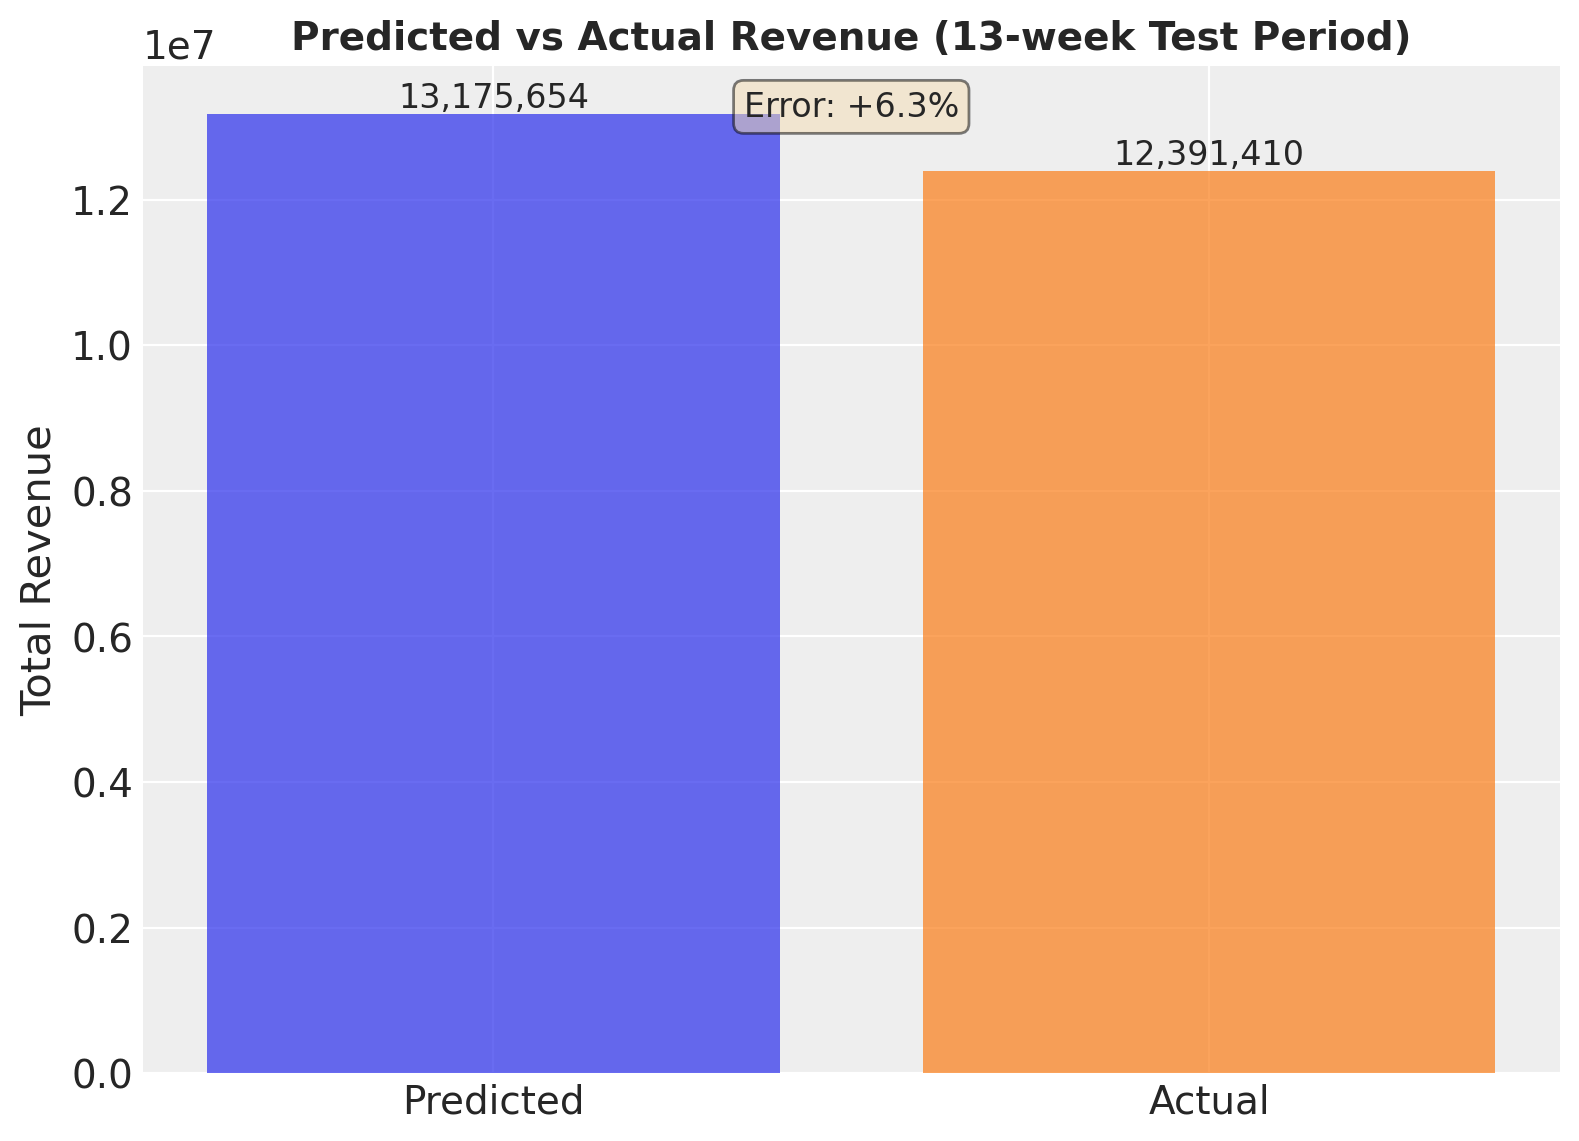

In [48]:
if total_clv_mean is not None:
    fig, ax = plt.subplots(figsize=(8, 6))

    bars = ax.bar(
        ["Predicted", "Actual"],
        [total_clv_mean, actual_total_revenue],
        color=["C0", "C1"],
        alpha=0.7,
    )

    ax.set_ylabel("Total Revenue")
    ax.set_title(
        f"Predicted vs Actual Revenue ({future_t_weeks:.0f}-week Test Period)",
        fontsize=14,
        fontweight="bold",
    )

    for bar, val in zip(bars, [total_clv_mean, actual_total_revenue], strict=True):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{val:,.0f}",
            ha="center",
            va="bottom",
            fontsize=12,
        )

    ax.annotate(
        f"Error: {prediction_error_pct:+.1f}%",
        xy=(0.5, 0.95),
        xycoords="axes fraction",
        ha="center",
        fontsize=12,
        bbox={"boxstyle": "round", "facecolor": "wheat", "alpha": 0.5},
    )

    plt.tight_layout()
    plt.show()

In [49]:
# --- Cohort-Level Evaluation Metrics ---

test_periods: list[date] = []
current = PERIOD_TRAIN_TEST_SPLIT
while current.weekday() != 0:
    current += timedelta(days=1)
while current < TEST_PERIOD_END:
    test_periods.append(current)
    current += timedelta(weeks=1)

actual_cohort_revenue = compute_actual_revenue_by_cohort(
    transactions_df=filtered_df,
    cohorts=list(cohort_results.keys()),
    data_start=DATA_START_DATE,
    data_end=TEST_PERIOD_END,
).filter(pl.col("period").is_in(test_periods))

pred_rows = []
for cohort_id, result in cohort_results.items():
    preds = compute_cohort_weekly_revenue_predictions(
        cohort_result=result,
        test_periods=test_periods,
        observation_end=PERIOD_TRAIN_TEST_SPLIT,
    )
    if preds is not None:
        pred_periods = [
            pd.Timestamp(p).date() for p in preds.coords["period"].to_numpy()
        ]
        pred_values = preds.to_numpy().flatten()
        for p, v in zip(pred_periods, pred_values, strict=True):
            pred_rows.append({"cohort": cohort_id, "period": p, "predicted_revenue": v})

pred_cohort_revenue = pl.DataFrame(pred_rows).sort(["cohort", "period"])

cohort_comparison_df = actual_cohort_revenue.join(
    pred_cohort_revenue, on=["cohort", "period"], how="inner"
).sort(["cohort", "period"])


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray, model_name: str) -> dict:
    """Compute evaluation metrics for a model."""
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {
        "Model": model_name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "MAPE (%)": round(mape, 2),
    }


y_true = cohort_comparison_df["revenue"].to_numpy()
y_pred = cohort_comparison_df["predicted_revenue"].to_numpy()

metrics_list = [
    compute_metrics(y_true, y_pred, "PyMC-Marketing (BG/NBD + Gamma-Gamma)"),
]

metrics_df = pd.DataFrame(metrics_list)

n_train_cohorts = len(cohort_results)
n_pred_cohorts = pred_cohort_revenue["cohort"].n_unique()
n_eval_pairs = cohort_comparison_df.height
n_eval_cohorts = cohort_comparison_df["cohort"].n_unique()
n_eval_periods = cohort_comparison_df["period"].n_unique()

print(f"Evaluation set: {n_eval_pairs} cohort-period pairs")
print(
    f"  Cohorts: {n_eval_cohorts} evaluated / {n_train_cohorts} trained / {n_train_cohorts - n_pred_cohorts} without predictions"  # noqa: E501
)
print(f"  Periods: {n_eval_periods}")
print()
metrics_df

Evaluation set: 732 cohort-period pairs
  Cohorts: 61 evaluated / 61 trained / 0 without predictions
  Periods: 12



,Model,MAE,RMSE,MAPE (%)
0,PyMC-Marketing (BG/NBD + Gamma-Gamma),1253.55,3100.92,8.7


### Revenue Over Time Plot

This visualization shows the posterior predictive revenue distribution over time,
with:
- **Black line/dots**: Actual revenue
- **Orange line**: Test period predictions (mean)
- **Dashed line**: Train/test split

Computing test period predictions...
Computing weekly predictions for 12 periods...
  Computed predictions for 12 periods


/var/folders/cm/3dzy9rdd5s3672z0s1brjkvh0000gn/T/ipykernel_60201/2865870806.py:69: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


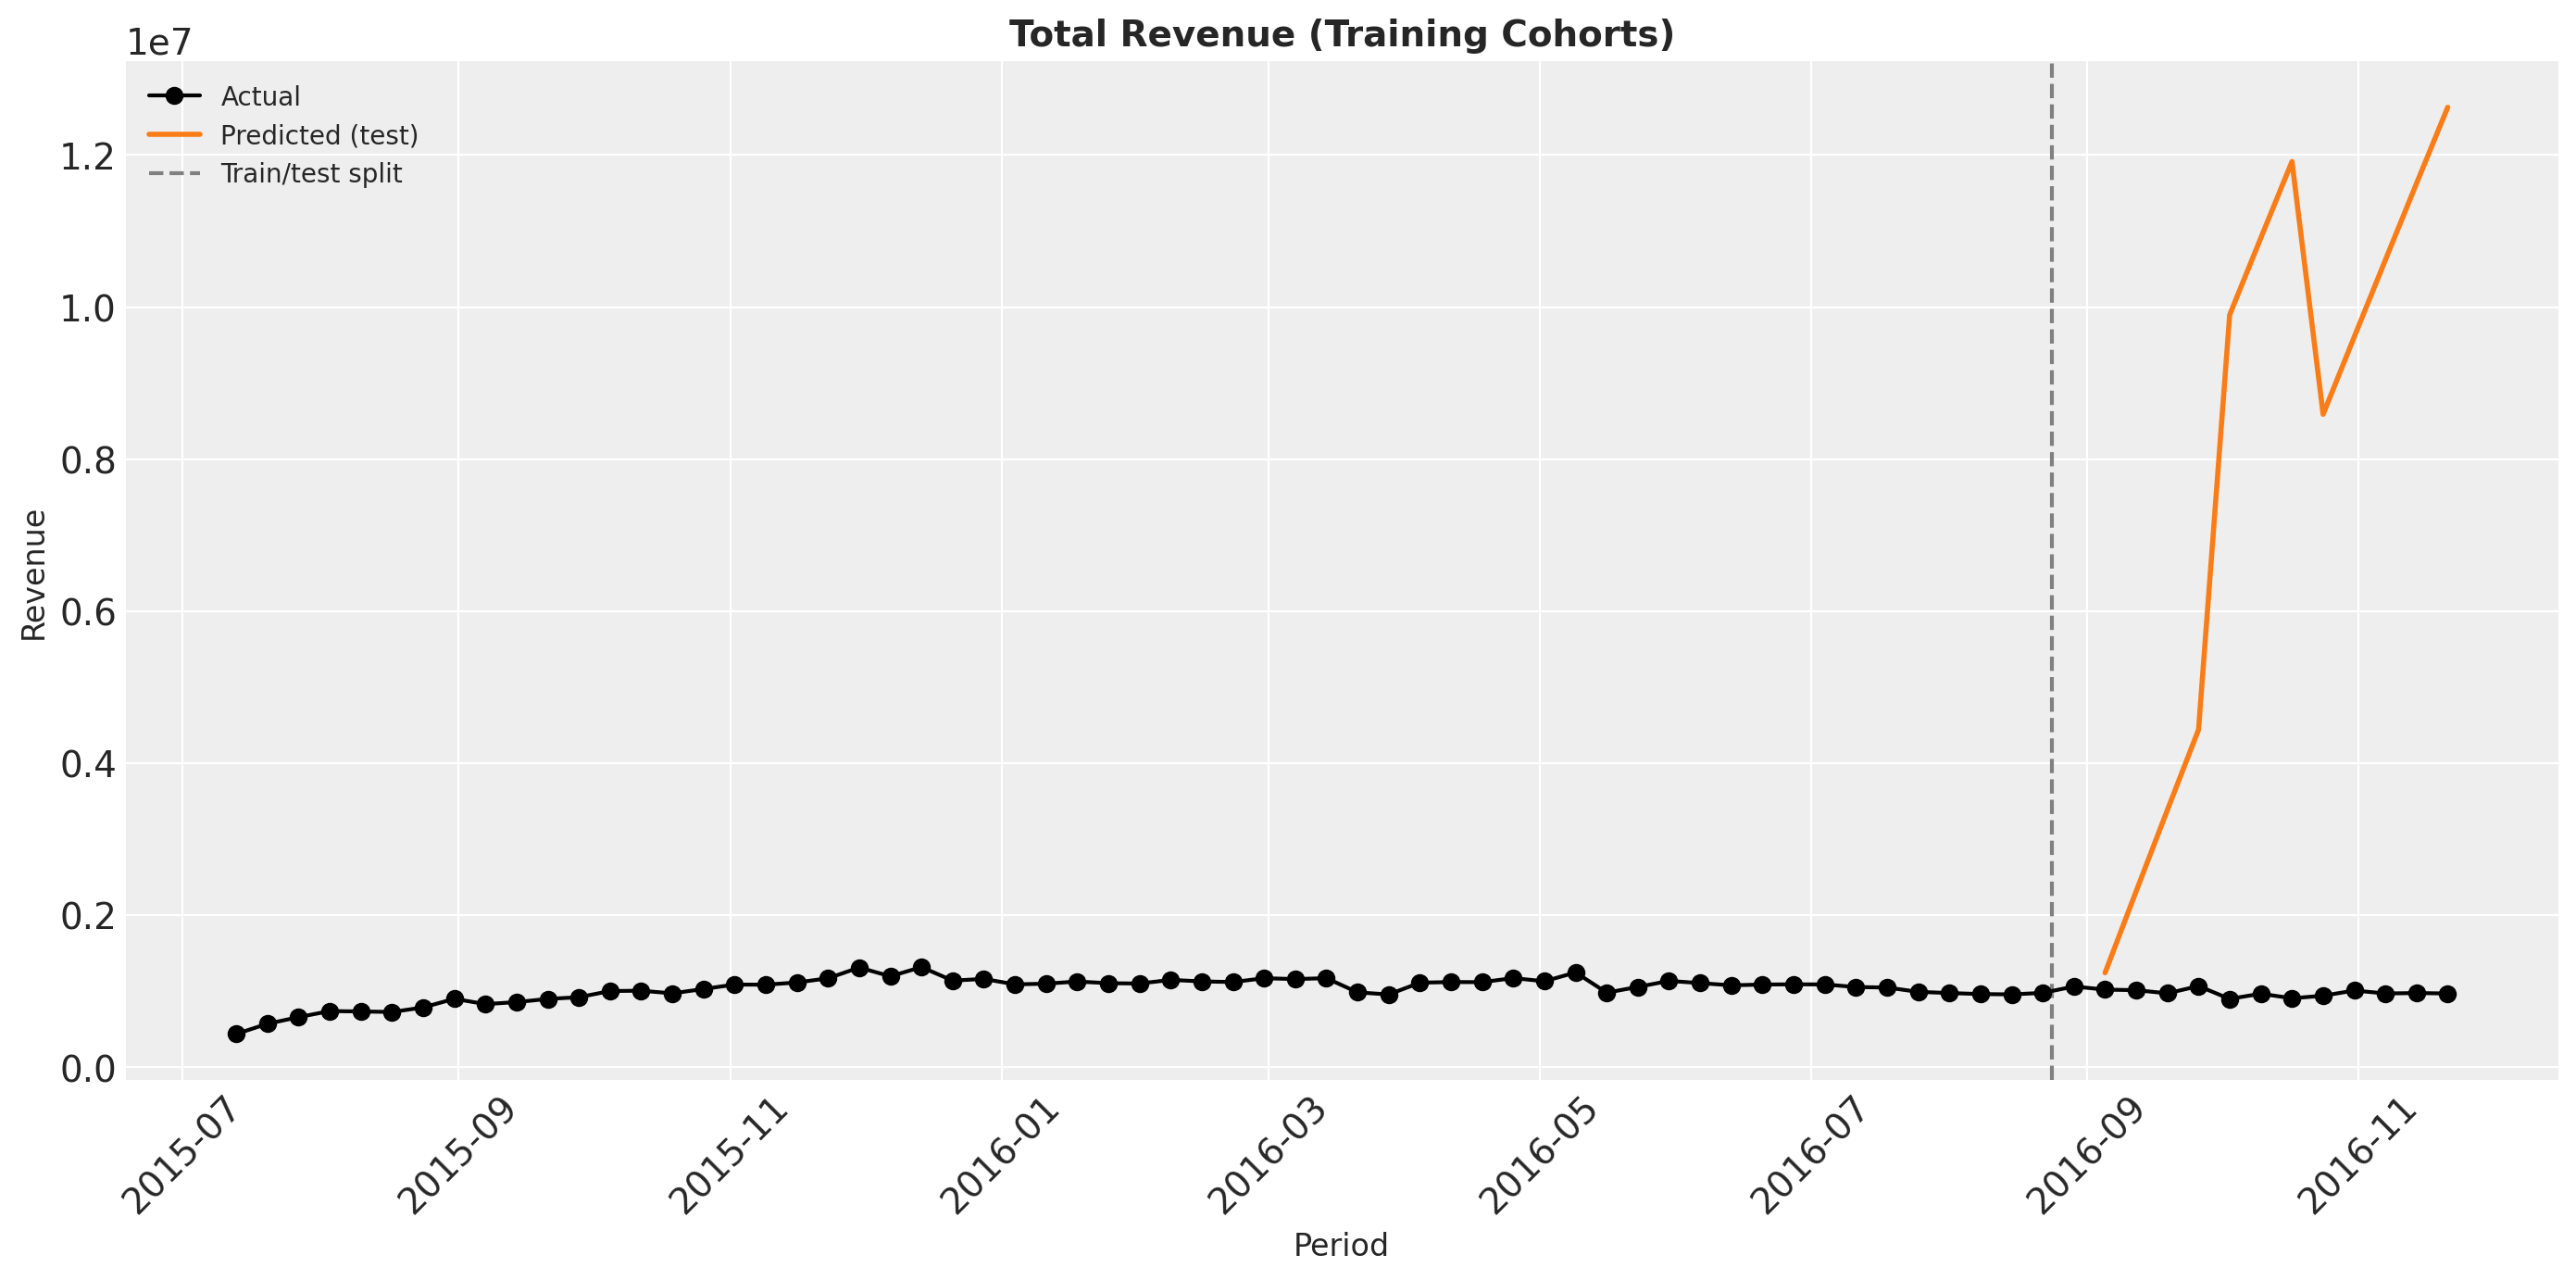

In [50]:
fig = plot_revenue_train_test(
    transactions_df=filtered_df,
    cohort_results=cohort_results,
    train_test_split=PERIOD_TRAIN_TEST_SPLIT,
    test_end=TEST_PERIOD_END,
    data_start=DATA_START_DATE,
    figsize=(14, 7),
    title="Total Revenue (Training Cohorts)",
)
plt.show()

### Out-of-Sample Revenue Predictions by Cohort

Generate faceted plots showing revenue predictions for each cohort.

For each cohort we show:
- **Blue line/dots**: Training period observed revenue
- **Orange line**: Test period posterior mean prediction
- **Black dots**: Test period observed revenue
- **Dashed line**: Train/test split

In [51]:
all_cohorts = sorted(cohort_results.keys())
n_available_cohorts = len(all_cohorts)

indices = np.linspace(
    0, n_available_cohorts - 1, min(8, n_available_cohorts), dtype=int
)
cohorts_to_plot = [all_cohorts[i] for i in indices]

print(f"Plotting {len(cohorts_to_plot)} cohorts:")
for c in cohorts_to_plot:
    status = "OK" if c in cohort_results else "no model"
    print(f"  - {c} ({status})")

Plotting 8 cohorts:
  - 2015-07-06 (OK)
  - 2015-08-31 (OK)
  - 2015-11-02 (OK)
  - 2015-12-28 (OK)
  - 2016-02-29 (OK)
  - 2016-04-25 (OK)
  - 2016-06-27 (OK)
  - 2016-08-29 (OK)


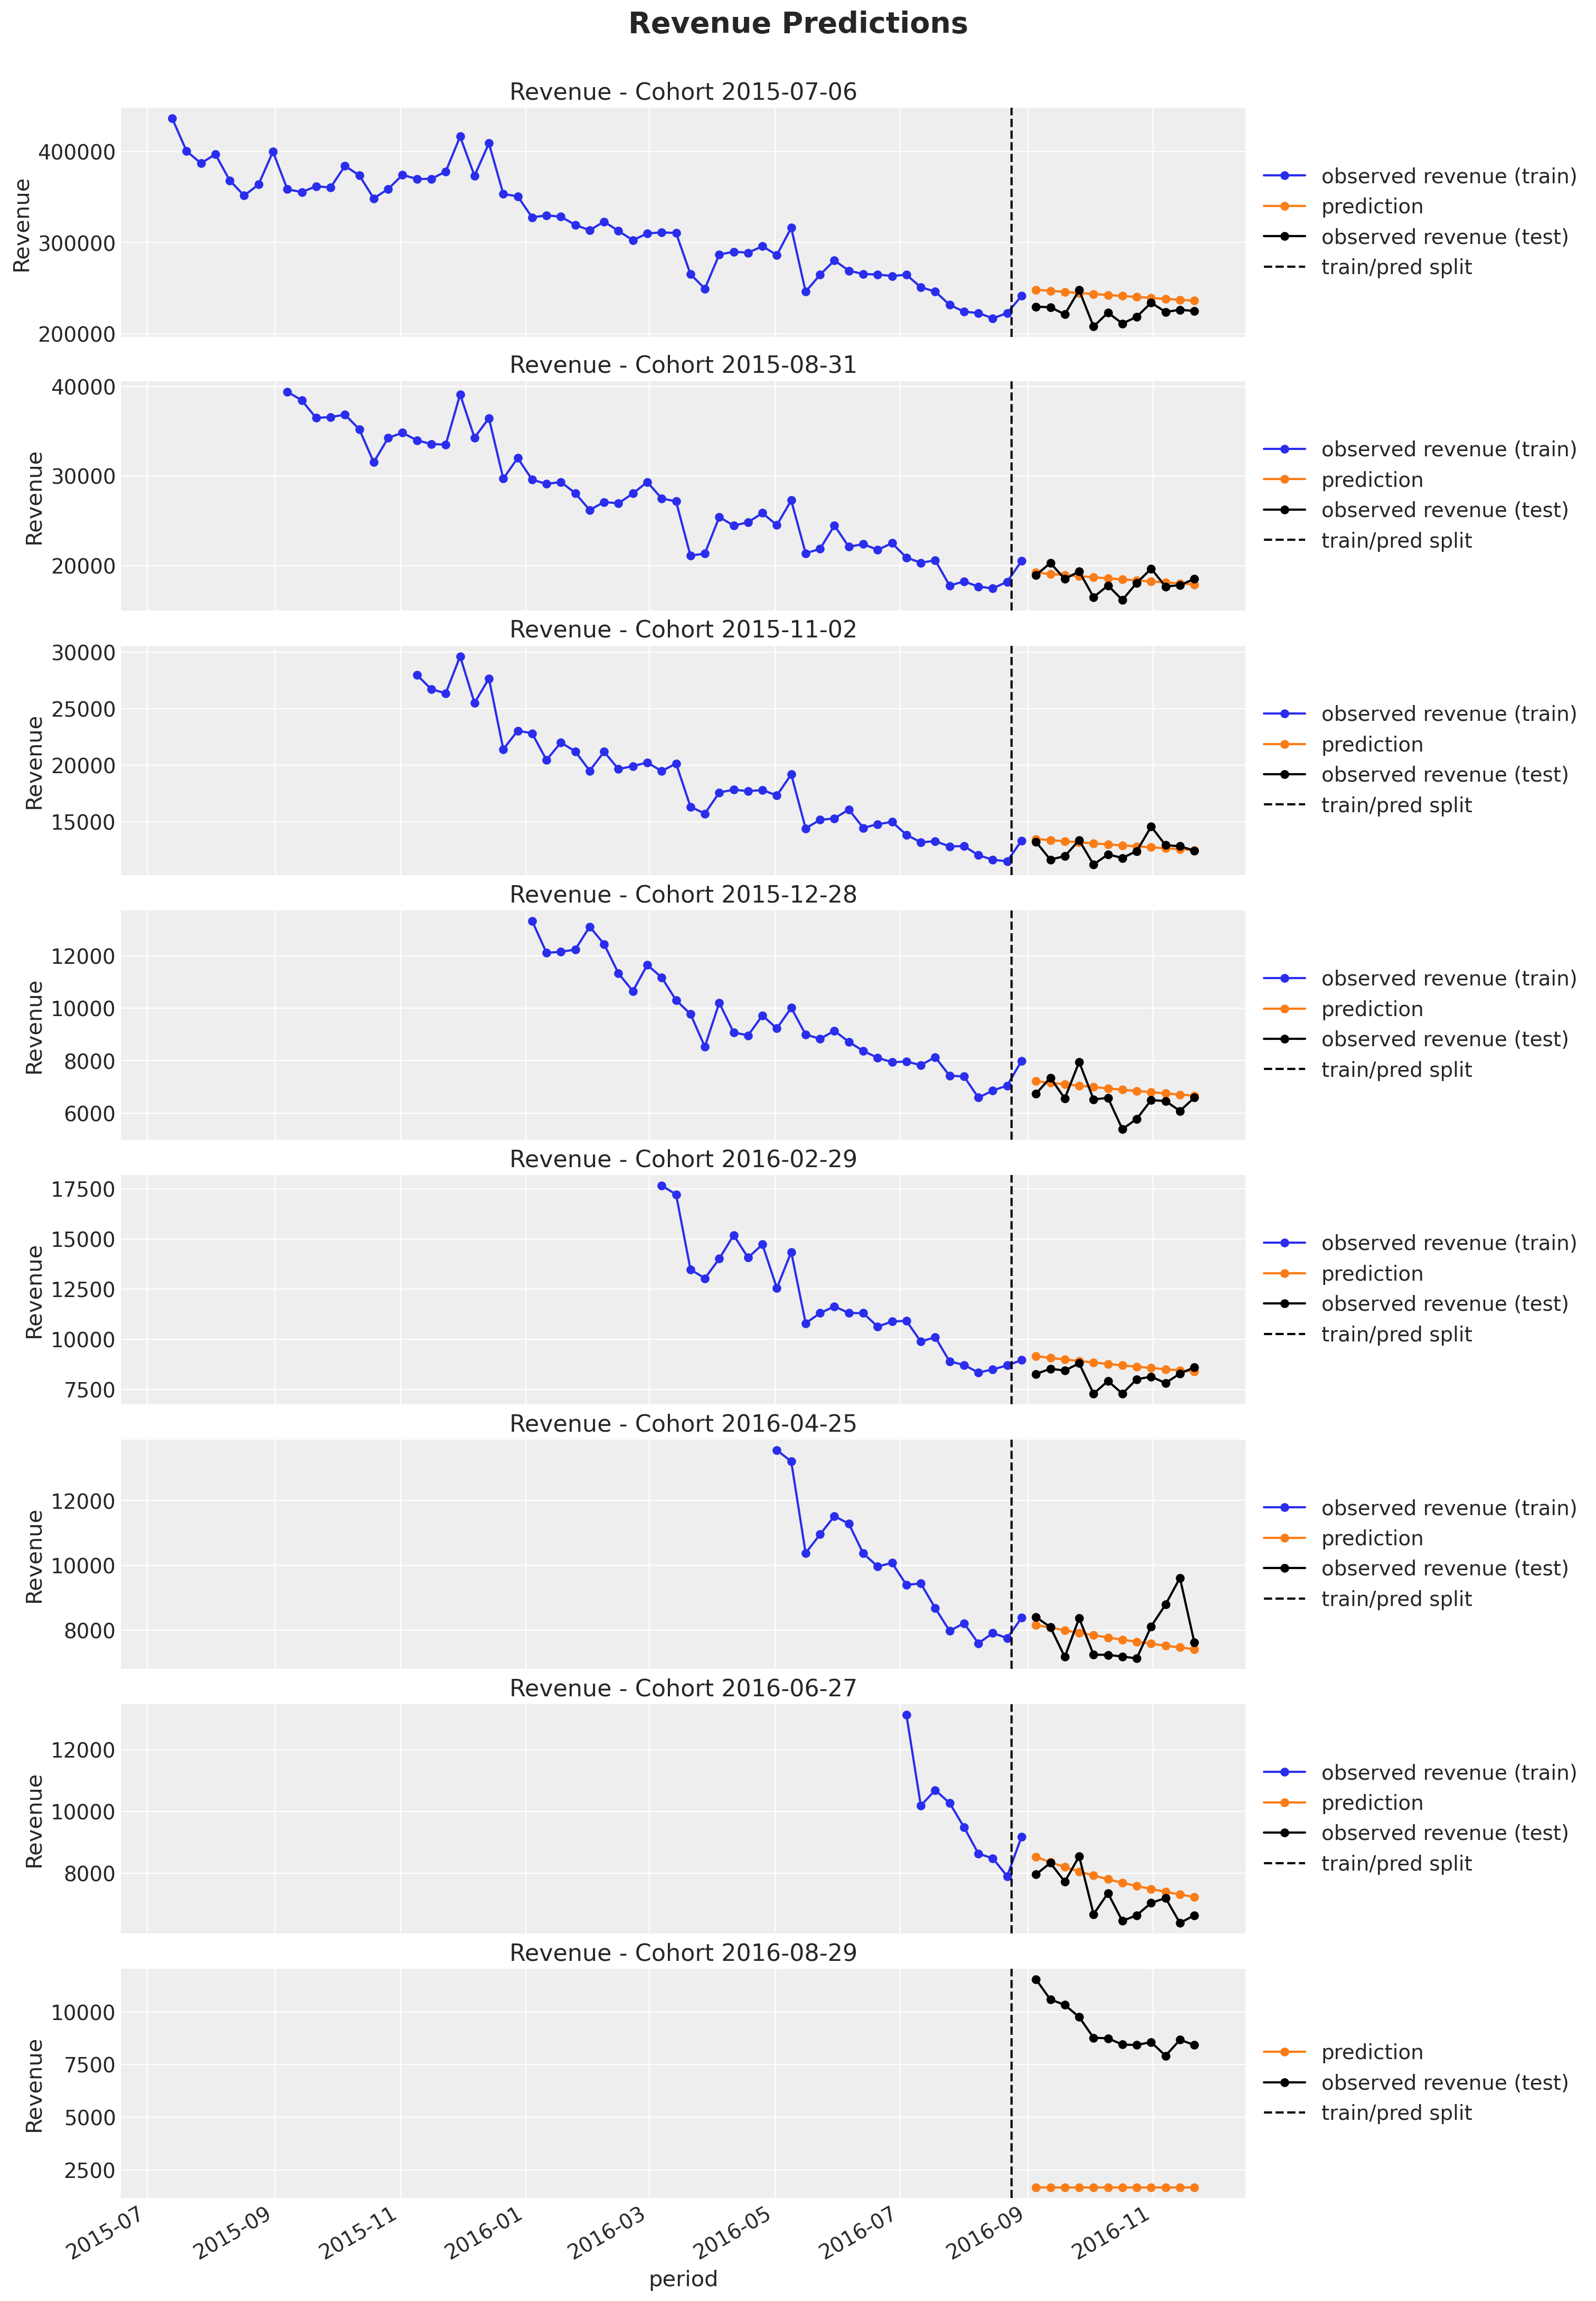

In [52]:
fig = plot_cohort_revenue_predictions(
    cohort_results=cohort_results,
    transactions_df=filtered_df,
    cohorts_to_plot=cohorts_to_plot,
    train_test_split=PERIOD_TRAIN_TEST_SPLIT,
    test_end=TEST_PERIOD_END,
    data_start=DATA_START_DATE,
    figsize=(15, 21),
)
plt.show()

---
## 14. Summary and Conclusions

### Key Findings

1. **Cohort-Based Approach**: By fitting separate models per weekly cohort, we can
   handle the KT dataset efficiently.

2. **Weekly Granularity**: Using weekly cohorts provides finer temporal resolution
   than monthly cohorts, but results in smaller cohort sizes.

3. **Model Performance**: Compare the prediction error to evaluate model quality.

### MAP Convergence: Progressive Prior Tightening

Weekly cohorts may have fewer customers, making MAP estimation more challenging.
The progressive fallback strategy (default -> tight -> very tight priors)
helps ensure convergence for cohorts with extreme data characteristics.

### Limitations

1. **BG/NBD Assumptions**: The model assumes stationary purchase rates, which
   may not hold for seasonal data. The KT dataset has notable Black Friday,
   Christmas, and Easter effects (see `kt_weekly.py`).

2. **Cohort Independence**: We treat cohorts independently, not accounting for
   potential cross-cohort effects.

3. **Small Cohorts**: Weekly cohorts have fewer customers than monthly cohorts,
   which may lead to less stable parameter estimates.

### Next Steps

1. Compare with the BART-based cohort model from `kt_weekly.py`
2. Try MCMC fitting for uncertainty quantification
3. Explore cohort-specific seasonality patterns

In [53]:
print("\n" + "=" * 60)
print("COHORT-BASED CLV MODEL SUMMARY")
print("=" * 60)
print("\nConfiguration:")
print(f"  MAX_COHORT_SIZE: {MAX_COHORT_SIZE}")
print("  Fit Method: MAP")
print("  Time Unit: Weeks")

print("\nData Summary:")
print(f"  Cohorts from: {COHORT_START_DATE}")
print(f"  Training Period: {DATA_START_DATE} to {PERIOD_TRAIN_TEST_SPLIT}")
print(f"  Test Period: {PERIOD_TRAIN_TEST_SPLIT} to {TEST_PERIOD_END}")
print(f"  Number of Cohorts: {len(cohort_results)}")
print(f"  Total Training Customers: {train_rfm_df.height:,}")

print("\nModel Results:")
total_fit_time = sum(r["fit_time"] for r in cohort_results.values())
print(f"  Total Fitting Time: {total_fit_time:.1f}s ({total_fit_time / 60:.1f} min)")

if total_clv_mean is not None:
    print("\nPrediction Results:")
    print(f"  Forecast Horizon: {future_t_weeks:.1f} weeks")
    print(f"  Predicted Revenue: {total_clv_mean:,.2f}")
    print(f"  Actual Revenue: {actual_total_revenue:,.2f}")
    print(f"  Prediction Error: {prediction_error_pct:+.1f}%")

print("=" * 60)


COHORT-BASED CLV MODEL SUMMARY

Configuration:
  MAX_COHORT_SIZE: None
  Fit Method: MAP
  Time Unit: Weeks

Data Summary:
  Cohorts from: 2015-07-01
  Training Period: 2015-07-01 to 2016-08-31
  Test Period: 2016-08-31 to 2016-11-28
  Number of Cohorts: 61
  Total Training Customers: 349,553

Model Results:
  Total Fitting Time: 227.9s (3.8 min)

Prediction Results:
  Forecast Horizon: 12.7 weeks
  Predicted Revenue: 13,175,653.59
  Actual Revenue: 12,391,410.02
  Prediction Error: +6.3%


In [54]:
%load_ext watermark
%watermark -n -u -v -iv -w

Last updated: Sun, 29 Mar 2026

Python implementation: CPython
Python version       : 3.13.12
IPython version      : 9.11.0

arviz         : 0.23.4
matplotlib    : 3.10.8
numpy         : 2.4.3
pandas        : 3.0.1
polars        : 1.39.3
pymc_extras   : 0.8.0
pymc_marketing: 0.18.2
xarray        : 2026.2.0

Watermark: 2.6.0

